<a href="https://colab.research.google.com/github/atanasovmi/Quantum-/blob/main/QAOA_MAXCUT_instructor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# CELL 1: SETUP
# ==========================================
!pip install qiskit[visualization] qiskit-ibm-runtime networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.6/378.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d9b3559f7225fe732cbdc817f320d14590c40d5b1691bc254e3f005638e03ac5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
✅ Setup Complete!


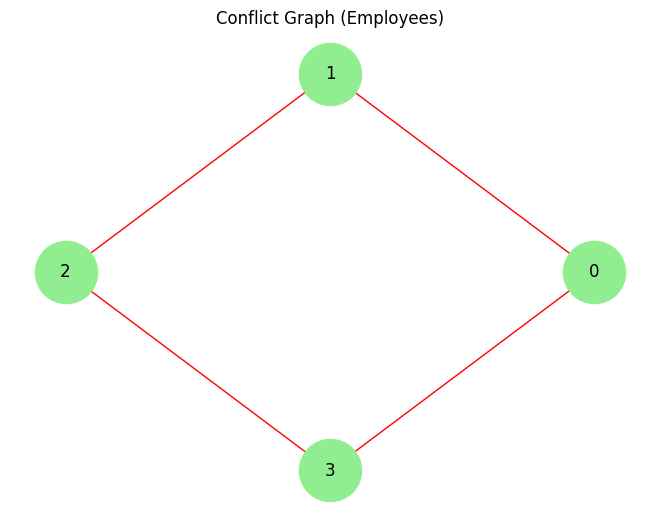

In [ ]:
# ==========================================
# PART 1: THE BUSINESS PROBLEM
# ==========================================
# Graph: A square cycle 0-1-2-3-0
conflicts = [(0, 1), (1, 2), (2, 3), (3, 0)]

G = nx.Graph()
G.add_edges_from(conflicts)
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='red', node_size=2000)
plt.title("Conflict Graph (Employees)")
plt.show()

In [ ]:
# ==========================================
# SOLUTION 1: DEFINE THE COST FUNCTION
# ==========================================
# We want to Maximize the Cut.
# The Hamiltonian for MaxCut is typically sum(Z_i * Z_j).
# Qiskit is Little Endian (Right to Left): q3 q2 q1 q0

pauli_list = [
    ("IIZZ", 1.0),  # q0 and q1 (indices 0 and 1 from right)
    ("IZZI", 1.0),  # q1 and q2
    ("ZZII", 1.0),  # q2 and q3
    ("ZIIZ", 1.0)   # q3 and q0
]

# Note: The specific coefficients (1.0 vs -0.5) determine if we are finding min or max energy.
# For educational purposes, just seeing the structure is enough.
cost_operator = SparsePauliOp.from_list(pauli_list)

print("--- Hamiltonian Constructed ---")
print(cost_operator)

--- Hamiltonian Constructed ---
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


--- The Circuit ---


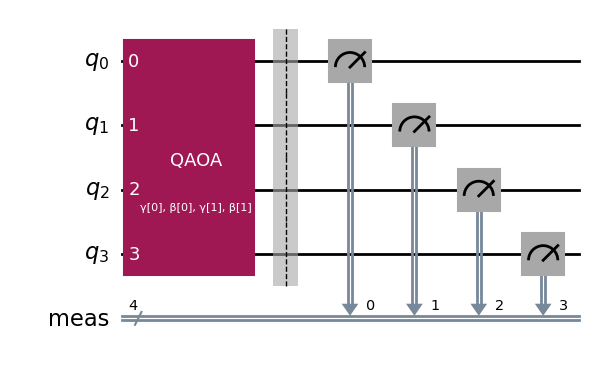

In [ ]:
# ==========================================
# SOLUTION 2: THE QAOA CIRCUIT
# ==========================================

# QAOAAnsatz automatically builds the "Mixer" and "Cost" layers
qaoa_circuit = QAOAAnsatz(cost_operator, reps=2)
qaoa_circuit.measure_all()

print("--- The Circuit ---")
qaoa_circuit.draw('mpl', fold=-1)

Testing Angles: [4.86290927 2.75755456 5.39472984 4.38169255]


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


--- Results ---


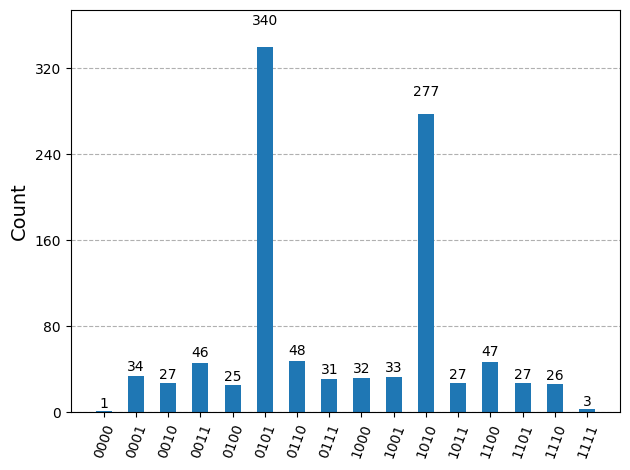

In [ ]:
# ==========================================
# SOLUTION 3: OPTIMIZATION (SIMULATED)
# ==========================================

# In a real app, we would loop this. Here we try one random guess.
rng = np.random.default_rng(seed=42) # Fixed seed for consistent demo
num_params = qaoa_circuit.num_parameters
random_angles = rng.uniform(0, 2*np.pi, num_params)

print(f"Testing Angles: {random_angles}")

# Run Sampler
sampler = StatevectorSampler()
job = sampler.run([(qaoa_circuit, random_angles)])
result = job.result()[0]
counts = result.data.meas.get_counts()

print("--- Results ---")
# Filter low counts for cleaner plot
filtered_counts = {k: v for k, v in counts.items() if v > 50}
plot_histogram(counts)

In [ ]:
# ==========================================
# EXPLANATION OF RESULTS
# ==========================================
# You should see high probabilities for '0101' and '1010'.
# Let's decode '0101':
# q3=0, q2=1, q1=0, q0=1
# Team A: {3, 1}
# Team B: {2, 0}
# Checking the graph:
# 3 is connected to 2 and 0. They are in opposite teams. Good!
# 1 is connected to 2 and 0. They are in opposite teams. Good!
# This is an optimal solution.